# 01 ? Official data audit

**Problem:** predict survival in Kaggle?s historical Titanic benchmark. **Audience:** technical recruiters and data practitioners. **Input:** official passenger-manifest covariates. **Transformation:** schema, missingness, distribution, parser, and group-structure audit. **Output:** aggregate evidence that the data and feature foundations are suitable for leakage-safe modeling. **Value:** modeling begins from verified data rather than assumptions.

This notebook renders saved aggregate artifacts from the authoritative run. It does not display passenger-level outcomes or use the unlabeled test set for model selection.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
REPORTS = ROOT / "reports"
audit = json.loads((REPORTS / "metrics" / "data_audit.json").read_text())
manifest = json.loads((REPORTS / "data_manifest.json").read_text())
environment = json.loads((REPORTS / "environment.json").read_text())
{
    "train_shape": audit["schema"]["train_shape"],
    "test_shape": audit["schema"]["test_shape"],
    "survival_rate": round(audit["target"]["proportions"]["1"], 4),
    "python": environment["python"],
    "scikit_learn": environment["packages"]["scikit-learn"],
}

{'train_shape': [891, 12],
 'test_shape': [418, 11],
 'survival_rate': 0.3838,
 'python': '3.12.5',
 'scikit_learn': '1.9.0'}

## Data integrity and missingness

The official files contain 891 training rows and 418 test rows. Passenger IDs are unique, the training target is binary, the sample submission has the required schema, and there are no exact duplicate rows. Missing cabin values dominate both partitions; age also requires fold-fitted imputation, while embarkation and fare each have only a small number of missing values.

In [2]:
missing = pd.DataFrame({
    "train_missing": audit["missing_counts"]["train"],
    "test_missing": audit["missing_counts"]["test"],
}).fillna(0).astype(int)
missing.loc[(missing != 0).any(axis=1)]

,train_missing,test_missing
Age,177,86
Cabin,687,327
Embarked,2,0
Fare,0,1


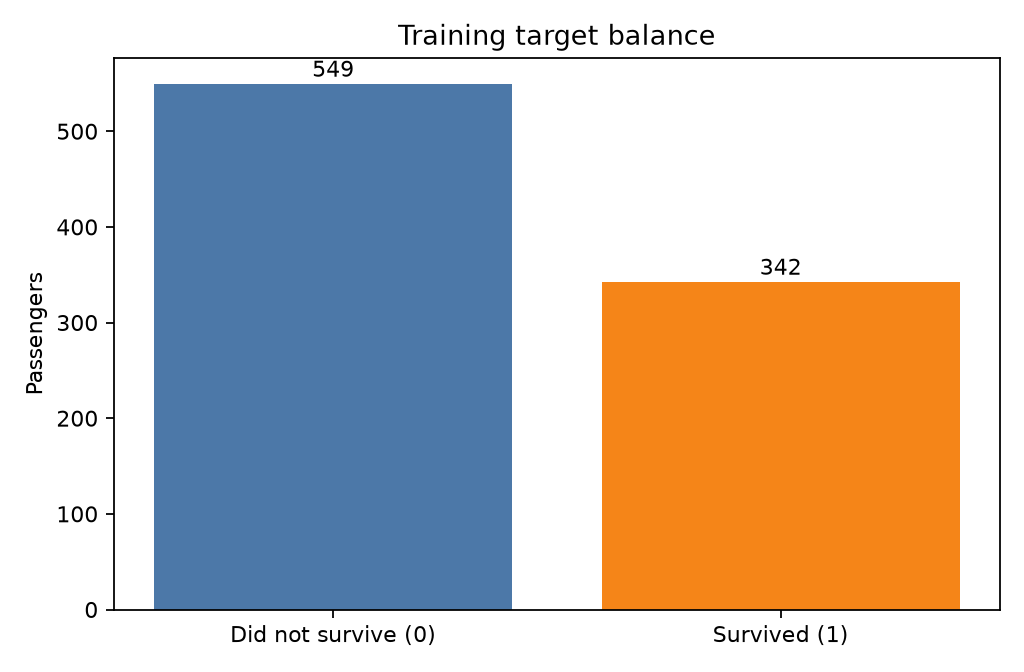

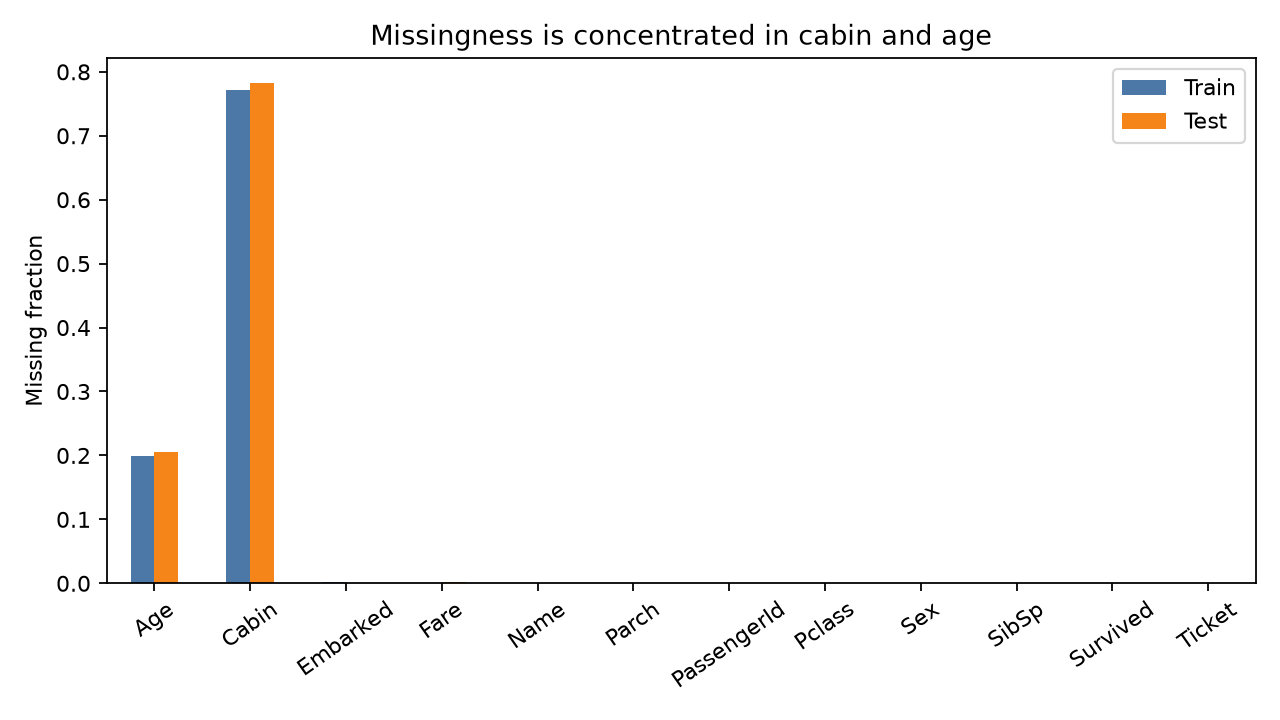

In [3]:
display(Image(filename=str(REPORTS / "figures" / "target_balance.png"), width=560))
display(Image(filename=str(REPORTS / "figures" / "missingness.png"), width=720))

## Observed associations and covariate checks

These plots are descriptive rather than causal. Sex and passenger class are strongly associated with the observed training labels, which explains why a sex-only rule is a meaningful reference. Age, fare, family composition, and missingness motivate candidate features. Train/test comparisons use covariates only; they do not reveal or reconstruct test outcomes.

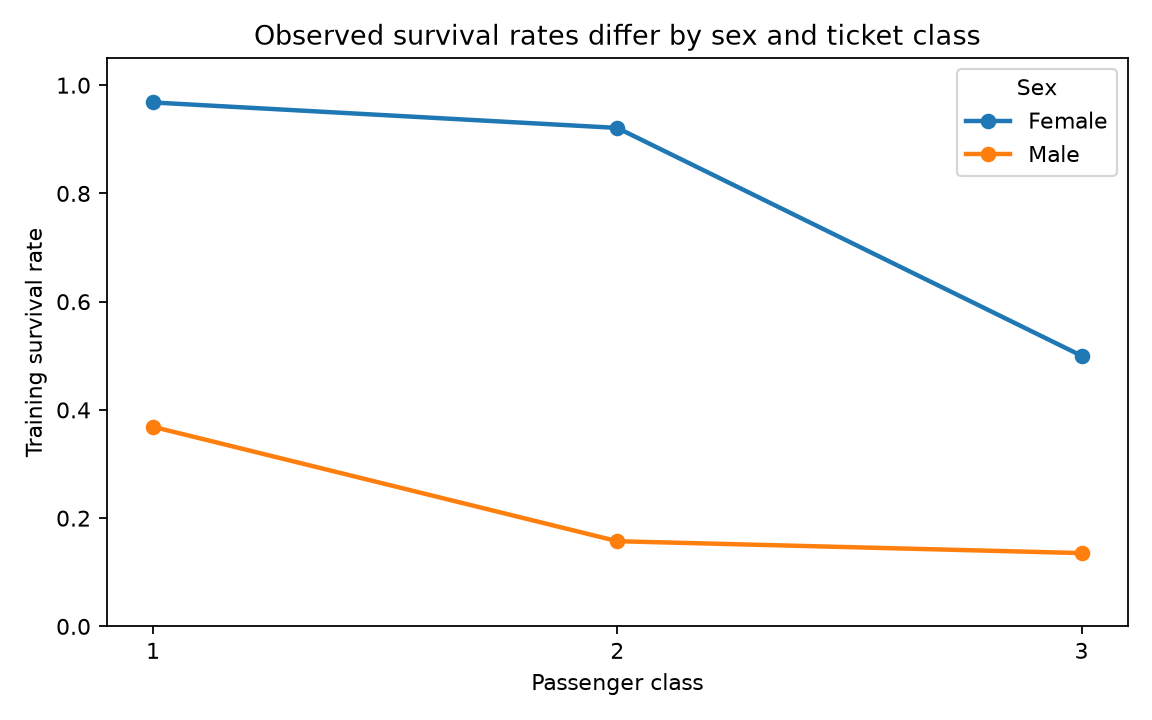

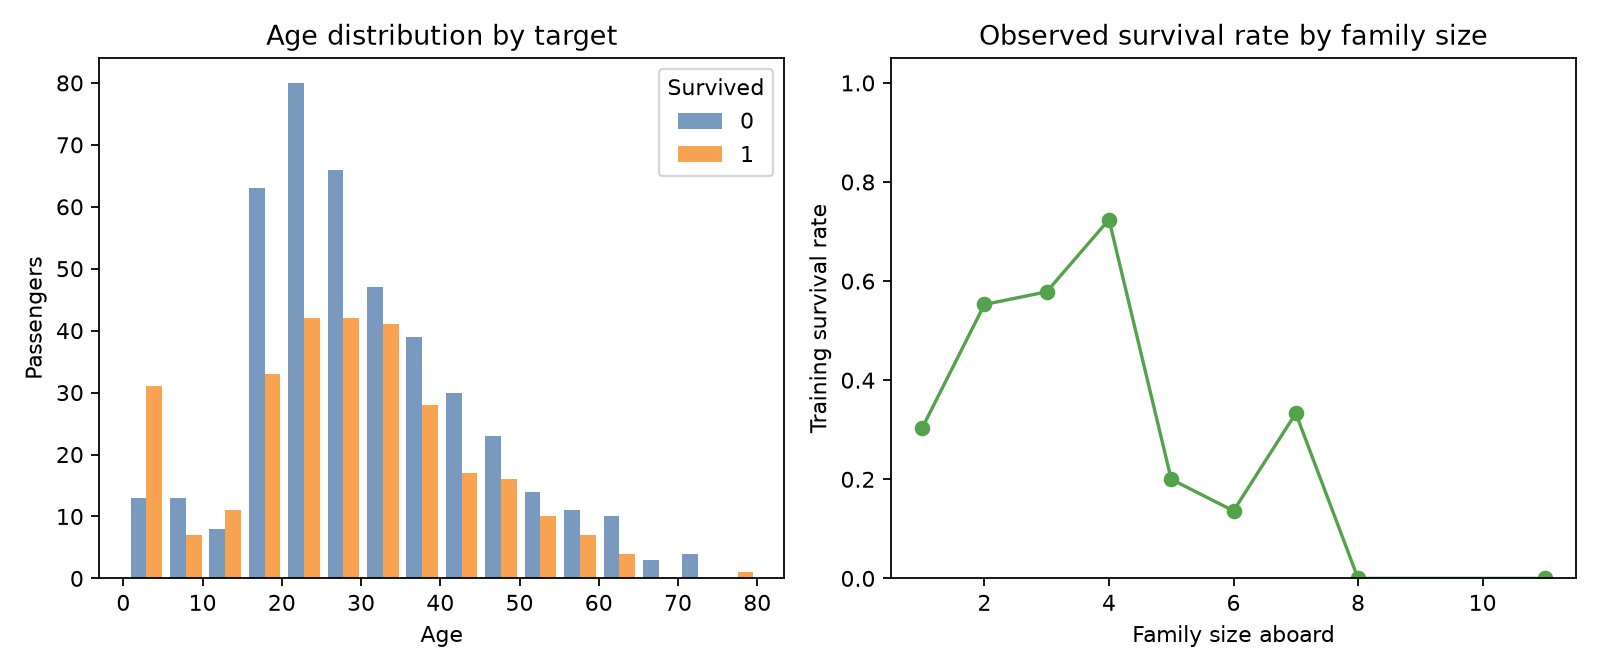

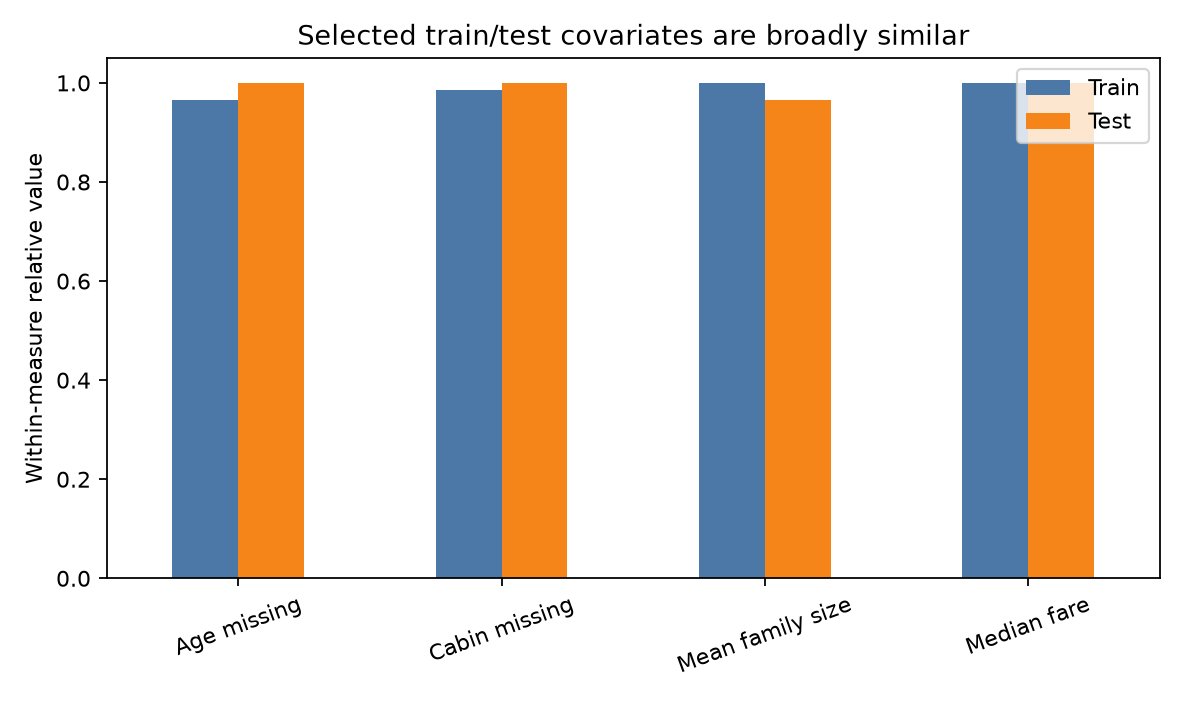

In [4]:
display(Image(filename=str(REPORTS / "figures" / "survival_by_sex_class.png"), width=720))
display(Image(filename=str(REPORTS / "figures" / "age_and_family_patterns.png"), width=720))
display(Image(filename=str(REPORTS / "figures" / "train_test_covariate_comparison.png"), width=720))

## Audit decisions

Title, surname, ticket, cabin, and family parsers covered all rows with explicit unknown fallbacks. Repeated family and ticket groups justify separate group-aware stress tests. Target-derived group priors were omitted because many repeated groups contain conflicting labels and the leakage-safe complexity was not justified. Train/test-combined counts, external data, and historical label corrections were not used.

In [5]:
pd.DataFrame({
    "decision": audit["decisions"],
})

,decision
0,Merge 'the Countess' into the normalized Nobil...
1,Add NumberOfCabins because multi-cabin strings...
2,"Retain AgeMissing, FareMissing, LogFare, and c..."
3,Fit ticket/family count mappings on each train...
4,Do not use target-derived group priors: many r...
5,Do not use transductive train/test counts beca...
